In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import pymc as pm
import pytensor as pt
import arviz as az
import arviz_plots as azp
import japanize_matplotlib
from statsmodels.tsa.stattools import acf
import pytensor
import pytensor.tensor as pt

In [2]:
df = yf.download("^N225", start="2015-01-01", end="2026-07-07")
df = df[["Close"]].dropna()
df.to_csv("../data/nikkei225.csv")

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Close
Ticker,^N225
Date,
2015-01-05,17408.710938
2015-01-06,16883.189453
2015-01-07,16885.330078
2015-01-08,17167.099609
2015-01-09,17197.730469


In [4]:
df["Return"] = np.log(df["Close"] / df["Close"].shift(1))
df["Return"]

Date
2015-01-05         NaN
2015-01-06   -0.030652
2015-01-07    0.000127
2015-01-08    0.016550
2015-01-09    0.001783
                ...   
2026-06-30    0.008517
2026-07-01    0.005872
2026-07-02   -0.025026
2026-07-03    0.014601
2026-07-06   -0.000092
Name: Return, Length: 2811, dtype: float64

In [5]:
r = df["Return"].dropna().values
n = len(r)
with pm.Model() as model_n225_v0:
    phi_raw = pm.Beta("phi_raw", alpha=20, beta=1.5)
    phi = pm.Deterministic("phi", 2 * phi_raw - 1)
    
    mu = pm.Normal("mu", mu=np.log(np.var(r)), sigma=2)
    
    sigma_eta = pm.HalfNormal("sigma_eta", sigma=0.15)

    init_dist = pm.Normal.dist(0, 1 / pm.math.sqrt(1 - phi ** 2))
    w = pm.AR("w", rho=phi, sigma=1.0, init_dist=init_dist, shape=n)

    h = pm.Deterministic("h", mu + sigma_eta * w)
                
    sigma_t = pm.Deterministic("sigma_t", pm.math.exp(h / 2))

    r_obs = pm.Normal("r_obs", mu=0, sigma=sigma_t, observed=r)

    idata = pm.sample(draws=2000, tune=2000, chains=4, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [phi_raw, mu, sigma_eta, w]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 43 seconds.


In [6]:
az.summary(idata, var_names=["phi", "mu", "sigma_eta"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
phi,0.915,0.017,0.89,0.94,571,995,1.00,0.00072,0.00053
mu,-9.054,0.089,-9.2,-8.9,906,1297,1.00,0.003,0.0023
sigma_eta,0.355,0.038,0.3,0.42,477,973,1.00,0.0018,0.0013


In [7]:
idata.sample_stats.diverging.sum().item()

0

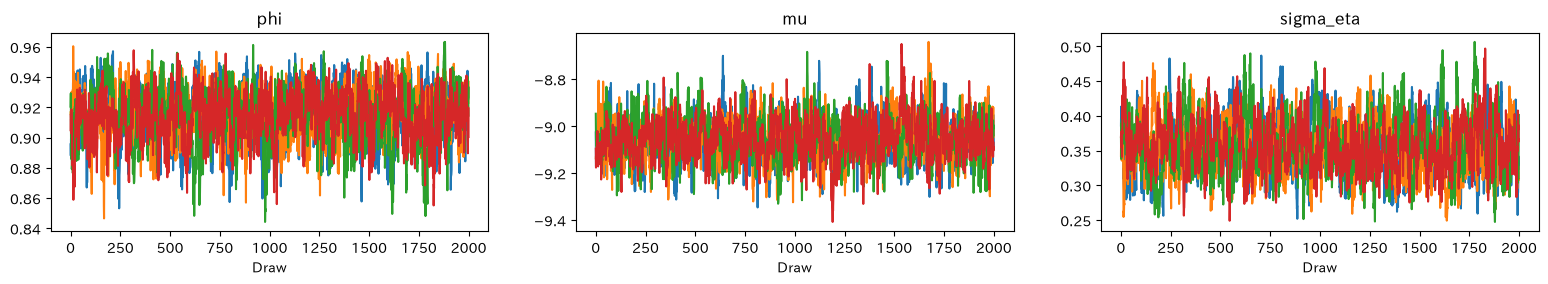

In [8]:
az.plot_trace(idata, var_names=["phi", "mu", "sigma_eta"])

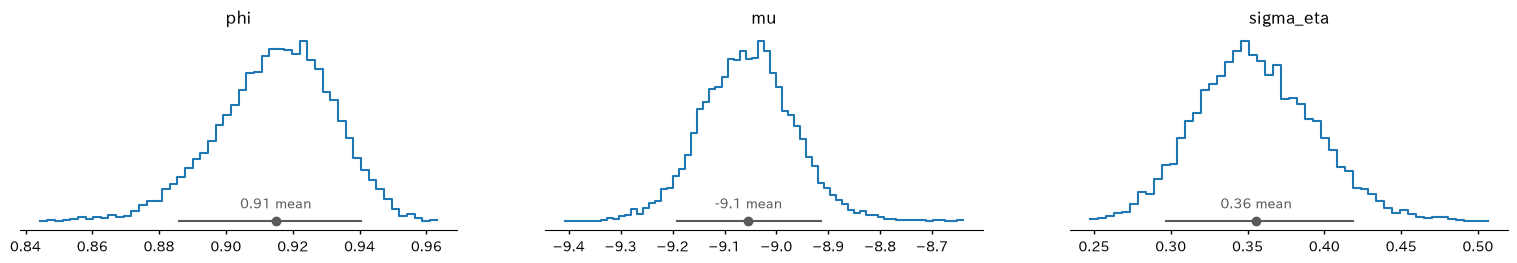

In [9]:
azp.plot_dist(idata, kind="hist", var_names=["phi", "mu", "sigma_eta"])

In [10]:
type(r)

numpy.ndarray

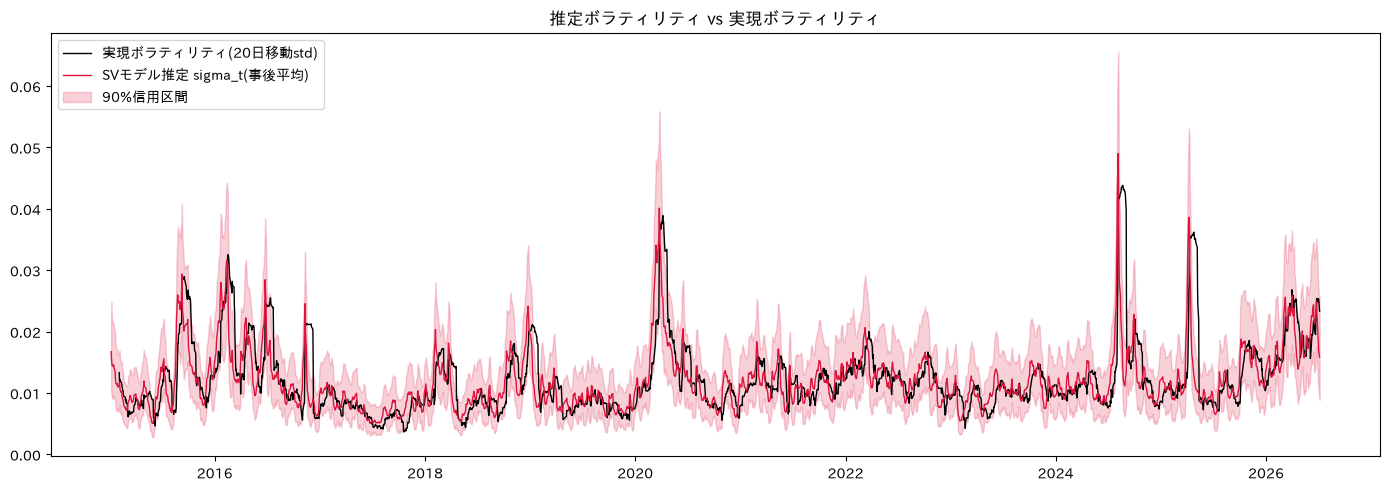

In [11]:
# --- 1. 推定ボラティリティ vs 実現ボラティリティ ---
h_posterior = idata.posterior["h"]
sigma_t_post = np.exp(h_posterior / 2)
sigma_t_stacked = sigma_t_post.stack(sample=("chain", "draw"))

sigma_mean = sigma_t_stacked.mean(dim="sample").values
sigma_lower = sigma_t_stacked.quantile(0.05, dim="sample").values
sigma_upper = sigma_t_stacked.quantile(0.95, dim="sample").values

realized_vol = pd.Series(r).rolling(20).std().values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[1:], realized_vol, color="black", lw=1, label="実現ボラティリティ(20日移動std)")
ax.plot(df.index[1:], sigma_mean, color="crimson", lw=1, label="SVモデル推定 sigma_t(事後平均)")
ax.fill_between(df.index[1:], sigma_lower, sigma_upper, color="crimson", alpha=0.2, label="90%信用区間")
ax.legend()
ax.set_title("推定ボラティリティ vs 実現ボラティリティ")
plt.tight_layout()
plt.savefig("col_comparison.png", dpi=100)


Sampling: [r_obs]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

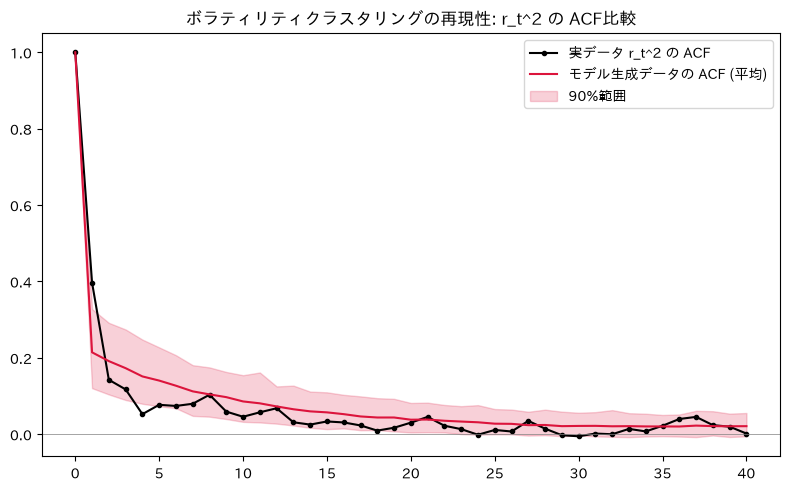

In [12]:
# --- 2. Posterior predictiveでボラティリティクラスタリングの再現性を検証 ---
with model_n225_v0:
    ppc = pm.sample_posterior_predictive(idata, var_names=["r_obs"], random_seed=42)

r_sim = ppc.posterior_predictive["r_obs"].stack(sample=("chain", "draw")).values.T

acf_real = acf(pd.Series(r).values**2, nlags=40)
acf_sims = np.array([acf(r_sim[i]**2, nlags=40) for i in range(min(200, r_sim.shape[0]))])
acf_sim_mean = acf_sims.mean(axis=0)
acf_sim_lower = np.percentile(acf_sims, 5, axis=0)
acf_sim_upper = np.percentile(acf_sims, 95, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
lags = np.arange(41)
ax.plot(lags, acf_real, color="black", marker="o", ms=3, label="実データ r_t^2 の ACF")
ax.plot(lags, acf_sim_mean, color="crimson", label="モデル生成データの ACF (平均)")
ax.fill_between(lags, acf_sim_lower, acf_sim_upper, color="crimson", alpha=0.2, label="90%範囲")
ax.axhline(0, color="gray", lw=0.5)
ax.legend()
ax.set_title("ボラティリティクラスタリングの再現性: r_t^2 の ACF比較")
plt.tight_layout()
plt.savefig("acf_comparison.png", dpi=100)


In [13]:
#正規分布仮定をstudent-t分布に仮定し、外れ値に対応できる観測分布にする

In [14]:
#観測分布をstudent-Tで考える
with pm.Model() as model_n225_v1:
    phi_raw = pm.Beta("phi_raw", alpha=20, beta=1.5)
    phi = pm.Deterministic("phi", 2 * phi_raw - 1)
    
    mu = pm.Normal("mu", mu=np.log(np.var(r)), sigma=2)
    
    sigma_eta = pm.HalfNormal("sigma_eta", sigma=0.15)

    init_dist = pm.Normal.dist(0, 1 / pm.math.sqrt(1 - phi ** 2))
    w = pm.AR("w", rho=phi, sigma=1.0, init_dist=init_dist, shape=n)

    h = pm.Deterministic("h", mu + sigma_eta * w)
                
    sigma_t = pm.Deterministic("sigma_t", pm.math.exp(h / 2))
    nu = pm.Gamma("nu", alpha=2, beta=0.1)

    r_obs = pm.StudentT("r_obs", nu=nu, mu=0, sigma=sigma_t, observed=r)

    idata = pm.sample(draws=2000, tune=2000, chains=4, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [phi_raw, mu, sigma_eta, w, nu]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 80 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [15]:
az.summary(idata, var_names=["phi", "nu", "mu", "sigma_eta"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
phi,0.941,0.016,0.91,0.96,407,684,1.01,0.00076,0.00061
nu,14.2,6.4,8.1,26,1020,2051,1.00,0.19,0.33
mu,-9.159,0.103,-9.3,-9,1085,1748,1.00,0.0031,0.0024
sigma_eta,0.276,0.041,0.21,0.34,364,561,1.01,0.0021,0.0015


In [16]:
idata.sample_stats.diverging.sum().item()

0

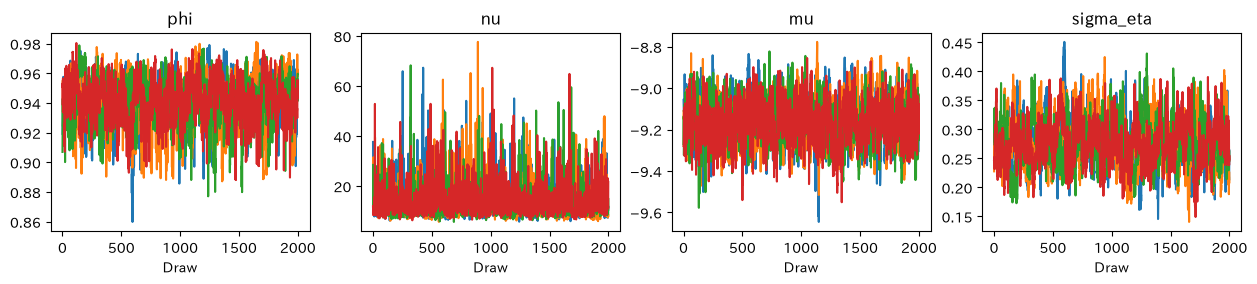

In [17]:
az.plot_trace(idata, var_names=["phi", "nu", "mu", "sigma_eta"])

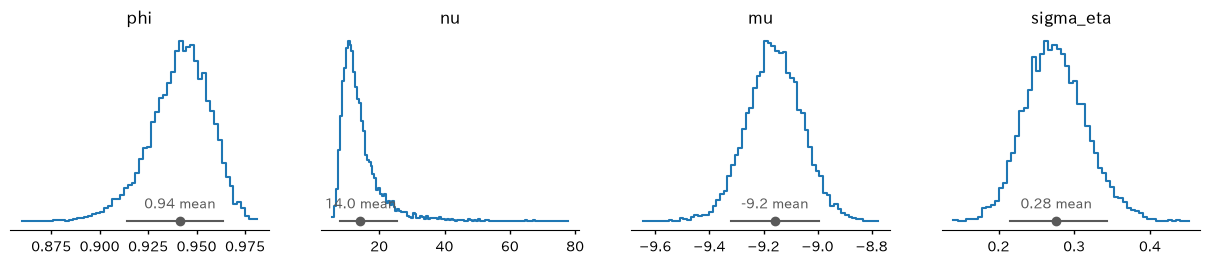

In [18]:
azp.plot_dist(idata, kind="hist", var_names=["phi", "nu", "mu", "sigma_eta"])

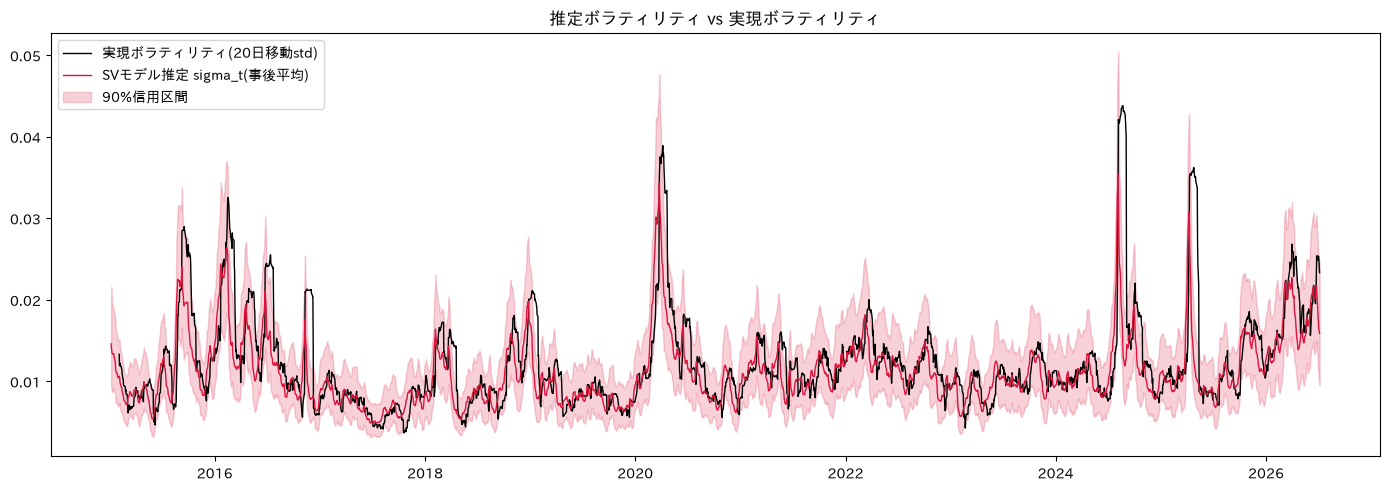

In [19]:
# --- 1. 推定ボラティリティ vs 実現ボラティリティ ---
h_posterior = idata.posterior["h"]
sigma_t_post = np.exp(h_posterior / 2)
sigma_t_stacked = sigma_t_post.stack(sample=("chain", "draw"))

sigma_mean = sigma_t_stacked.mean(dim="sample").values
sigma_lower = sigma_t_stacked.quantile(0.05, dim="sample").values
sigma_upper = sigma_t_stacked.quantile(0.95, dim="sample").values

realized_vol = pd.Series(r).rolling(20).std().values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[1:], realized_vol, color="black", lw=1, label="実現ボラティリティ(20日移動std)")
ax.plot(df.index[1:], sigma_mean, color="crimson", lw=1, label="SVモデル推定 sigma_t(事後平均)")
ax.fill_between(df.index[1:], sigma_lower, sigma_upper, color="crimson", alpha=0.2, label="90%信用区間")
ax.legend()
ax.set_title("推定ボラティリティ vs 実現ボラティリティ")
plt.tight_layout()
plt.savefig("col_comparison.png", dpi=100)


Sampling: [r_obs]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

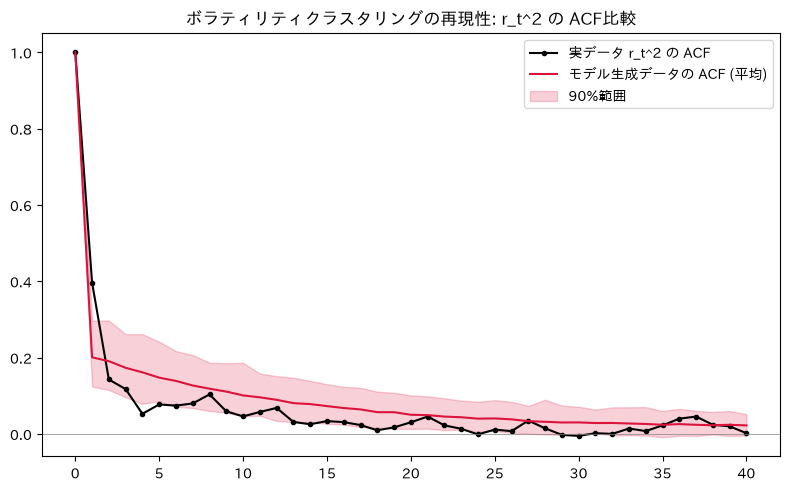

In [20]:
# --- 2. Posterior predictiveでボラティリティクラスタリングの再現性を検証 ---
with model_n225_v0:
    ppc = pm.sample_posterior_predictive(idata, var_names=["r_obs"], random_seed=42)

r_sim = ppc.posterior_predictive["r_obs"].stack(sample=("chain", "draw")).values.T

acf_real = acf(pd.Series(r).values**2, nlags=40)
acf_sims = np.array([acf(r_sim[i]**2, nlags=40) for i in range(min(200, r_sim.shape[0]))])
acf_sim_mean = acf_sims.mean(axis=0)
acf_sim_lower = np.percentile(acf_sims, 5, axis=0)
acf_sim_upper = np.percentile(acf_sims, 95, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
lags = np.arange(41)
ax.plot(lags, acf_real, color="black", marker="o", ms=3, label="実データ r_t^2 の ACF")
ax.plot(lags, acf_sim_mean, color="crimson", label="モデル生成データの ACF (平均)")
ax.fill_between(lags, acf_sim_lower, acf_sim_upper, color="crimson", alpha=0.2, label="90%範囲")
ax.axhline(0, color="gray", lw=0.5)
ax.legend()
ax.set_title("ボラティリティクラスタリングの再現性: r_t^2 の ACF比較")
plt.tight_layout()
plt.savefig("acf_comparison(student-T(nu=gamma)).png", dpi=100)


In [21]:
#観測分布をstudent-T(nu=Exponential)で考える
with pm.Model() as model_n225_v2:
    phi_raw = pm.Beta("phi_raw", alpha=20, beta=1.5)
    phi = pm.Deterministic("phi", 2 * phi_raw - 1)
    
    mu = pm.Normal("mu", mu=np.log(np.var(r)), sigma=2)
    
    sigma_eta = pm.HalfNormal("sigma_eta", sigma=0.15)

    init_dist = pm.Normal.dist(0, 1 / pm.math.sqrt(1 - phi ** 2))
    w = pm.AR("w", rho=phi, sigma=1.0, init_dist=init_dist, shape=n)

    h = pm.Deterministic("h", mu + sigma_eta * w)
                
    sigma_t = pm.Deterministic("sigma_t", pm.math.exp(h / 2))
    nu = pm.Exponential("nu", lam=1/30) + 1

    r_obs = pm.StudentT("r_obs", nu=nu, mu=0, sigma=sigma_t, observed=r)

    idata = pm.sample(draws=2000, tune=2000, chains=4, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [phi_raw, mu, sigma_eta, w, nu]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 80 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [22]:
az.summary(idata, var_names=["phi", "nu", "mu", "sigma_eta"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
phi,0.941,0.015,0.91,0.96,442,658,1.01,0.00072,0.00051
nu,14.5,10,7,30,976,1934,1.01,0.27,0.94
mu,-9.167,0.105,-9.3,-9,1039,1669,1.01,0.0033,0.0024
sigma_eta,0.278,0.041,0.21,0.35,393,564,1.01,0.0021,0.0014


In [23]:
idata.sample_stats.diverging.sum().item()

0

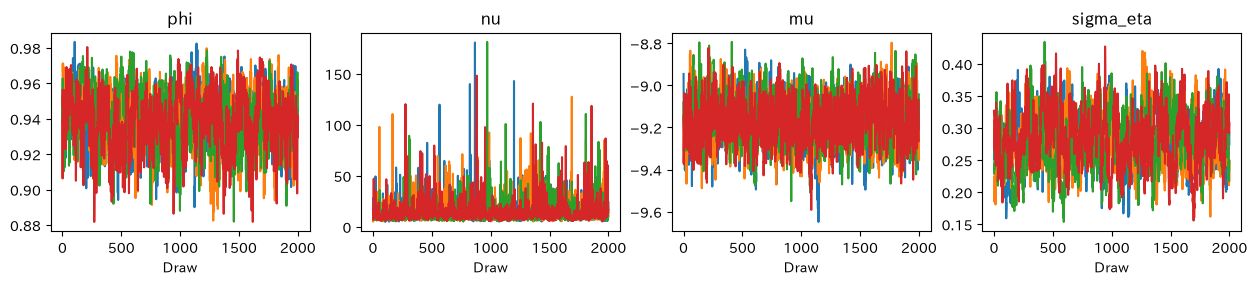

In [24]:
az.plot_trace(idata, var_names=["phi", "nu", "mu", "sigma_eta"])

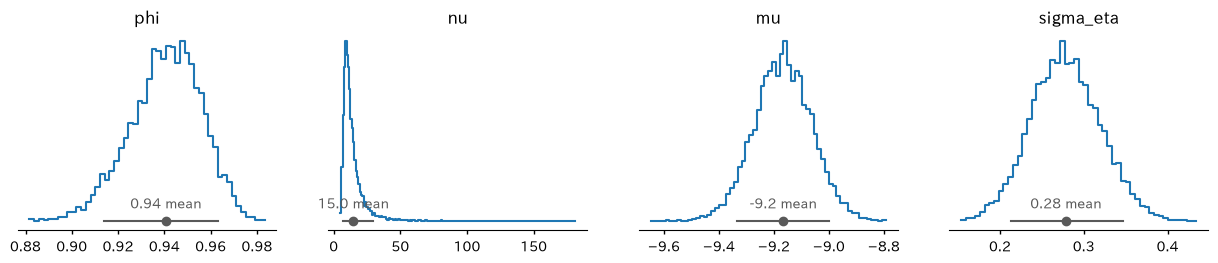

In [25]:
azp.plot_dist(idata, kind="hist", var_names=["phi", "nu", "mu", "sigma_eta"])

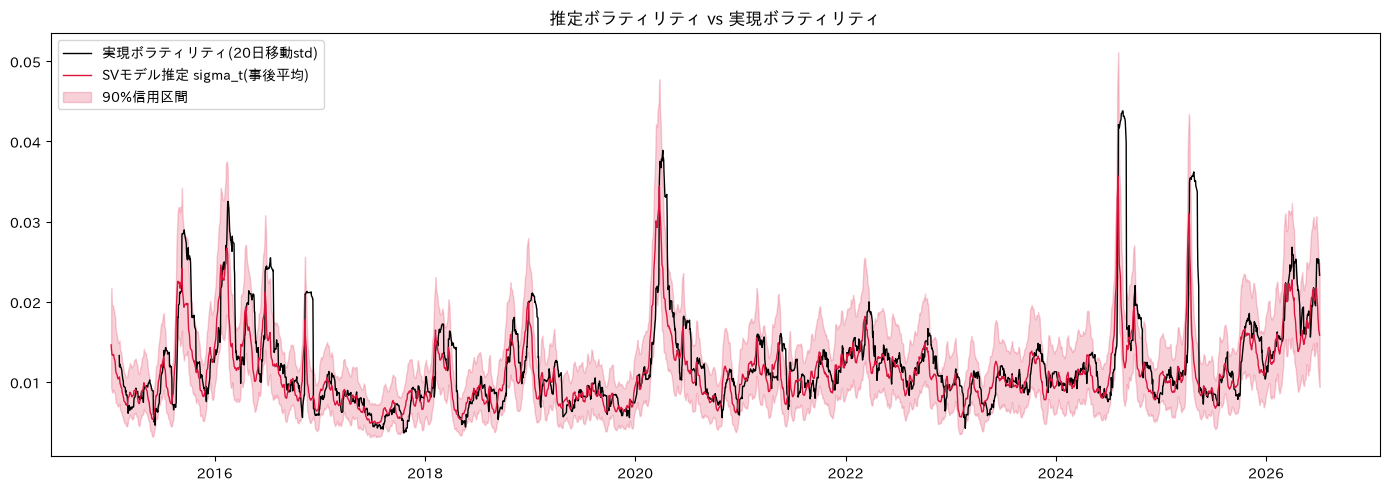

In [26]:
# --- 1. 推定ボラティリティ vs 実現ボラティリティ ---
h_posterior = idata.posterior["h"]
sigma_t_post = np.exp(h_posterior / 2)
sigma_t_stacked = sigma_t_post.stack(sample=("chain", "draw"))

sigma_mean = sigma_t_stacked.mean(dim="sample").values
sigma_lower = sigma_t_stacked.quantile(0.05, dim="sample").values
sigma_upper = sigma_t_stacked.quantile(0.95, dim="sample").values

realized_vol = pd.Series(r).rolling(20).std().values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[1:], realized_vol, color="black", lw=1, label="実現ボラティリティ(20日移動std)")
ax.plot(df.index[1:], sigma_mean, color="crimson", lw=1, label="SVモデル推定 sigma_t(事後平均)")
ax.fill_between(df.index[1:], sigma_lower, sigma_upper, color="crimson", alpha=0.2, label="90%信用区間")
ax.legend()
ax.set_title("推定ボラティリティ vs 実現ボラティリティ")
plt.tight_layout()
plt.savefig("col_comparison.png", dpi=100)


Sampling: [r_obs]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

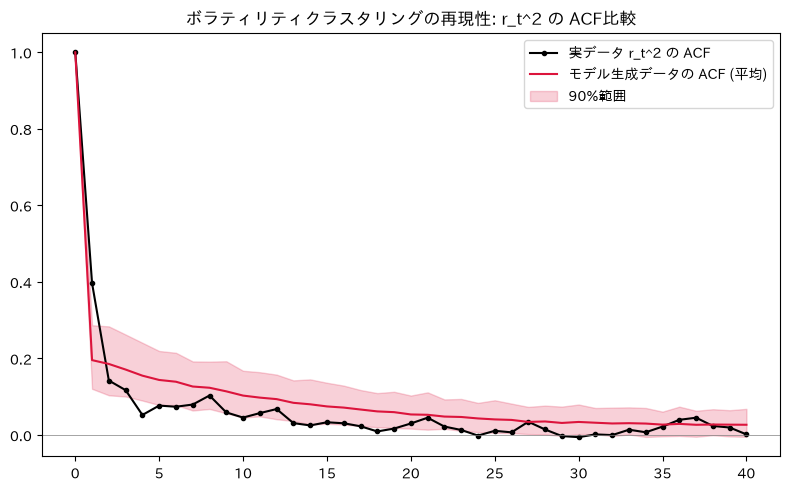

In [27]:
# --- 2. Posterior predictiveでボラティリティクラスタリングの再現性を検証 ---
with model_n225_v0:
    ppc = pm.sample_posterior_predictive(idata, var_names=["r_obs"], random_seed=42)

r_sim = ppc.posterior_predictive["r_obs"].stack(sample=("chain", "draw")).values.T

acf_real = acf(pd.Series(r).values**2, nlags=40)
acf_sims = np.array([acf(r_sim[i]**2, nlags=40) for i in range(min(200, r_sim.shape[0]))])
acf_sim_mean = acf_sims.mean(axis=0)
acf_sim_lower = np.percentile(acf_sims, 5, axis=0)
acf_sim_upper = np.percentile(acf_sims, 95, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
lags = np.arange(41)
ax.plot(lags, acf_real, color="black", marker="o", ms=3, label="実データ r_t^2 の ACF")
ax.plot(lags, acf_sim_mean, color="crimson", label="モデル生成データの ACF (平均)")
ax.fill_between(lags, acf_sim_lower, acf_sim_upper, color="crimson", alpha=0.2, label="90%範囲")
ax.axhline(0, color="gray", lw=0.5)
ax.legend()
ax.set_title("ボラティリティクラスタリングの再現性: r_t^2 の ACF比較")
plt.tight_layout()
plt.savefig("acf_comparison(student-T(nu=exponential)).png", dpi=100)


In [28]:
with pm.Model() as model_n225_leverage:

    phi_raw = pm.Beta("phi_raw", alpha=20, beta=1.5)
    phi = pm.Deterministic("phi", 2 * phi_raw - 1)

    mu = pm.Normal("mu", mu=np.log(np.var(r)), sigma=2)
    sigma_eta = pm.HalfNormal("sigma_eta", sigma=0.15)

    rho_raw = pm.Beta("rho_raw", alpha=2, beta=2)
    rho = pm.Deterministic("rho", 2 * rho_raw - 1)

    z1_raw = pm.Normal("z1_raw", 0, 1)
    w1 = z1_raw / pt.sqrt(1 - phi ** 2)

    v = pm.Normal("v", 0, 1, shape=n-1)

    def step(r_prev, v_t, w_prev, phi, sigma_eta, mu, rho):
        h_prev = mu + sigma_eta * w_prev
        sigma_prev = pt.exp(h_prev / 2)
        u_prev = r_prev / sigma_prev
        z_t = rho * u_prev + pt.sqrt(1 - rho**2) * v_t
        w_t = phi * w_prev + z_t
        return w_t
        
    r_tensor = pt.as_tensor_variable(r)

    w_rest, _ = pytensor.scan(
        fn=step,
        sequences=[r_tensor[:-1], v],
        outputs_info=[w1],
        non_sequences=[phi, sigma_eta, mu, rho],
    )

    w = pt.concatenate([[w1], w_rest])
    h = pm.Deterministic("h", mu + sigma_eta * w)
    sigma_t = pm.Deterministic("sigma_t", pt.exp(h / 2))
    

    r_obs = pm.Normal("r_obs", mu=0, sigma=sigma_t, observed=r)


/tmp/ipykernel_64915/213742475.py:27: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  w_rest, _ = pytensor.scan(


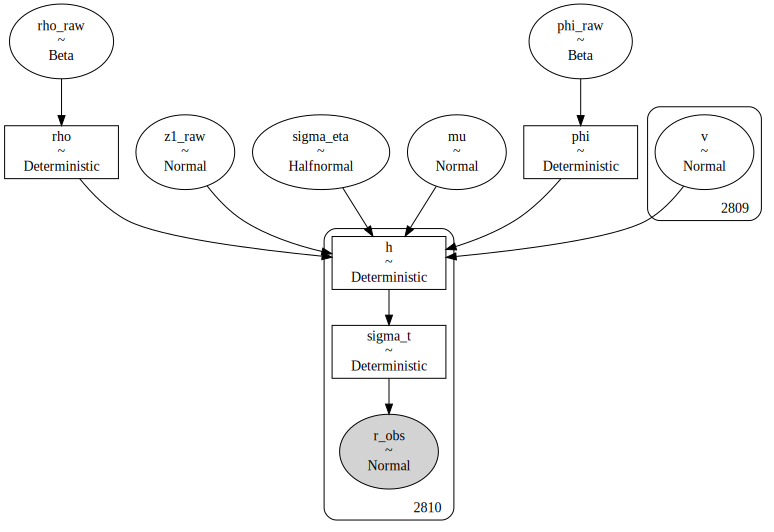

In [29]:
pm.model_to_graphviz(model_n225_leverage)

In [33]:
with pm.Model() as model_n225_leverage:

    phi_raw = pm.Beta("phi_raw", alpha=20, beta=1.5)
    phi = pm.Deterministic("phi", 2 * phi_raw - 1)

    mu = pm.Normal("mu", mu=np.log(np.var(r)), sigma=2)
    sigma_eta = pm.HalfNormal("sigma_eta", sigma=0.15)

    rho_raw = pm.Beta("rho_raw", alpha=2, beta=2)
    rho = pm.Deterministic("rho", 2 * rho_raw - 1)

    z1_raw = pm.Normal("z1_raw", 0, 1)
    w1 = z1_raw / pt.sqrt(1 - phi ** 2)

    v = pm.Normal("v", 0, 1, shape=n-1)

    def step(r_prev, v_t, w_prev, phi, sigma_eta, mu, rho):
        h_prev = mu + sigma_eta * w_prev
        sigma_prev = pt.exp(h_prev / 2)
        u_prev = r_prev / sigma_prev
        z_t = rho * u_prev + pt.sqrt(1 - rho**2) * v_t
        w_t = phi * w_prev + z_t
        return w_t
        
    r_tensor = pt.as_tensor_variable(r)

    w_rest, _ = pytensor.scan(
        fn=step,
        sequences=[r_tensor[:-1], v],
        outputs_info=[w1],
        non_sequences=[phi, sigma_eta, mu, rho],
    )

    w = pt.concatenate([[w1], w_rest])
    h = pm.Deterministic("h", mu + sigma_eta * w)
    sigma_t = pm.Deterministic("sigma_t", pt.exp(h / 2))
    

    r_obs = pm.Normal("r_obs", mu=0, sigma=sigma_t, observed=r)
    
    idata = pm.sample(draws=2000, tune=2000, chains=4, random_seed=42)

/tmp/ipykernel_64915/972858102.py:27: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  w_rest, _ = pytensor.scan(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [phi_raw, mu, sigma_eta, rho_raw, z1_raw, v]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 517 seconds.


In [34]:
az.summary(idata, var_names=["phi", "rho", "mu", "sigma_eta"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
phi,0.9195,0.0128,0.9,0.94,2818,4170,1.00,0.00024,0.00018
rho,-0.541,0.0469,-0.61,-0.46,5694,5456,1.00,0.00062,0.00044
mu,-8.954,0.077,-9.1,-8.8,7303,5714,1.00,0.00089,0.00065
sigma_eta,0.347,0.0299,0.3,0.4,3006,3948,1.00,0.00055,0.00039


In [35]:
idata.sample_stats.diverging.sum().item()

0

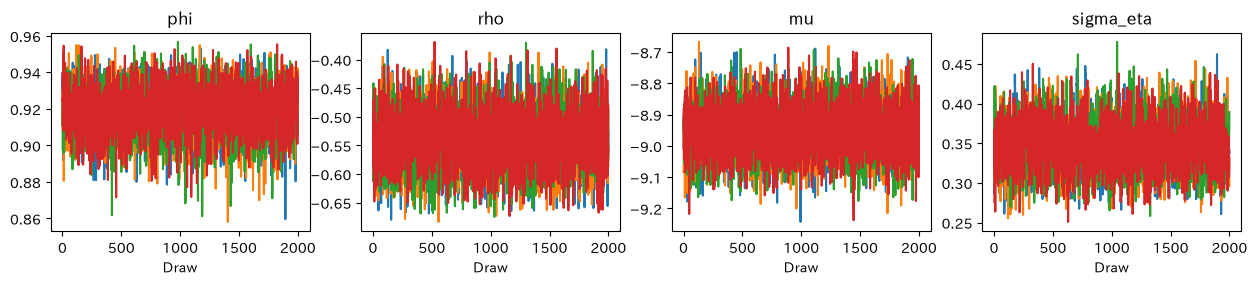

In [37]:
az.plot_trace(idata, var_names=["phi", "rho", "mu", "sigma_eta"])

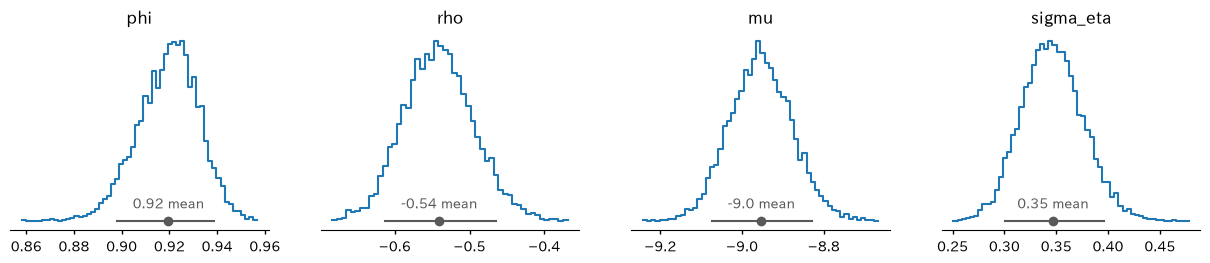

In [39]:
azp.plot_dist(idata, kind="hist", var_names=["phi", "rho", "mu", "sigma_eta"])

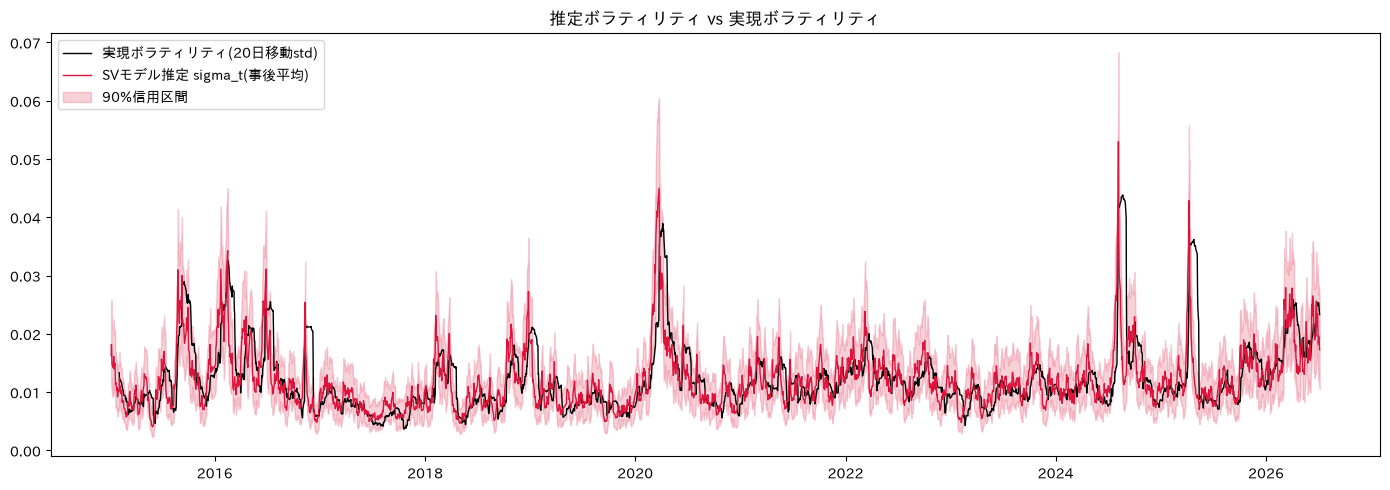

In [41]:
# --- 1. 推定ボラティリティ vs 実現ボラティリティ ---
h_posterior = idata.posterior["h"]
sigma_t_post = np.exp(h_posterior / 2)
sigma_t_stacked = sigma_t_post.stack(sample=("chain", "draw"))

sigma_mean = sigma_t_stacked.mean(dim="sample").values
sigma_lower = sigma_t_stacked.quantile(0.05, dim="sample").values
sigma_upper = sigma_t_stacked.quantile(0.95, dim="sample").values

realized_vol = pd.Series(r).rolling(20).std().values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[1:], realized_vol, color="black", lw=1, label="実現ボラティリティ(20日移動std)")
ax.plot(df.index[1:], sigma_mean, color="crimson", lw=1, label="SVモデル推定 sigma_t(事後平均)")
ax.fill_between(df.index[1:], sigma_lower, sigma_upper, color="crimson", alpha=0.2, label="90%信用区間")
ax.legend()
ax.set_title("推定ボラティリティ vs 実現ボラティリティ")
plt.tight_layout()
plt.savefig("col_comparison.png(Leverage SV モデル).png", dpi=100)


Sampling: [r_obs]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

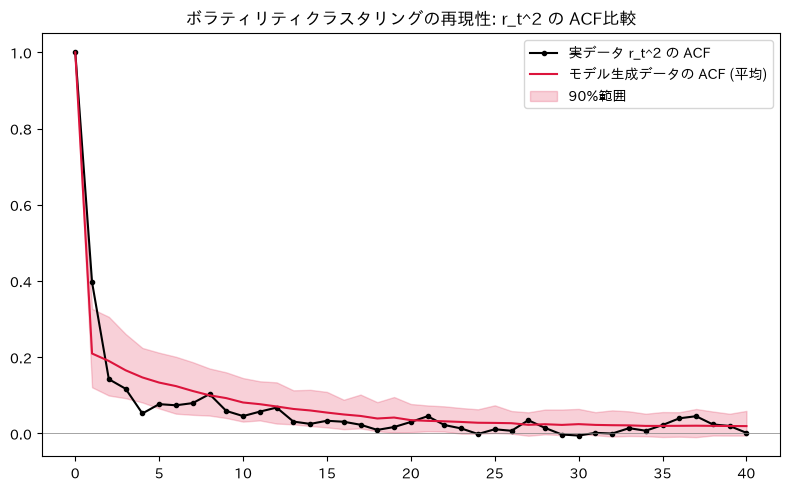

In [43]:
# --- 2. Posterior predictiveでボラティリティクラスタリングの再現性を検証 ---
with model_n225_leverage:
    ppc = pm.sample_posterior_predictive(idata, var_names=["r_obs"], random_seed=42)

r_sim = ppc.posterior_predictive["r_obs"].stack(sample=("chain", "draw")).values.T

acf_real = acf(pd.Series(r).values**2, nlags=40)
acf_sims = np.array([acf(r_sim[i]**2, nlags=40) for i in range(min(200, r_sim.shape[0]))])
acf_sim_mean = acf_sims.mean(axis=0)
acf_sim_lower = np.percentile(acf_sims, 5, axis=0)
acf_sim_upper = np.percentile(acf_sims, 95, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
lags = np.arange(41)
ax.plot(lags, acf_real, color="black", marker="o", ms=3, label="実データ r_t^2 の ACF")
ax.plot(lags, acf_sim_mean, color="crimson", label="モデル生成データの ACF (平均)")
ax.fill_between(lags, acf_sim_lower, acf_sim_upper, color="crimson", alpha=0.2, label="90%範囲")
ax.axhline(0, color="gray", lw=0.5)
ax.legend()
ax.set_title("ボラティリティクラスタリングの再現性: r_t^2 の ACF比較")
plt.tight_layout()
plt.savefig("acf_comparison(student-T(Leverage SV モデル)).png", dpi=100)


In [44]:

with pm.Model() as model_n225_2factor:
    mu = pm.Normal("mu", mu=np.log(np.var(r_vals)), sigma=2)

    # --- fast成分: 低め持続性に事前分布で強く制約 ---
    phi_fast_raw = pm.Beta("phi_fast_raw", alpha=2, beta=5)   # 平均0.29程度、0.7を超えにくい
    phi_fast = pm.Deterministic("phi_fast", phi_fast_raw)      # (0,1)のみ許容(負の持続性は今回不要)
    sigma_fast = pm.HalfNormal("sigma_fast", sigma=0.3)

    init_fast = pm.Normal.dist(0, 1 / pt.sqrt(1 - phi_fast**2))
    w_fast = pm.AR("w_fast", rho=phi_fast, sigma=1.0, init_dist=init_fast, shape=n)

    # --- slow成分: 高め持続性に強く制約(以前のphiに近いレンジ) ---
    phi_slow_raw = pm.Beta("phi_slow_raw", alpha=20, beta=1.5)  # 平均0.93程度
    phi_slow = pm.Deterministic("phi_slow", phi_slow_raw)
    sigma_slow = pm.HalfNormal("sigma_slow", sigma=0.15)

    init_slow = pm.Normal.dist(0, 1 / pt.sqrt(1 - phi_slow**2))
    w_slow = pm.AR("w_slow", rho=phi_slow, sigma=1.0, init_dist=init_slow, shape=n)

    # --- 合成 ---
    h = pm.Deterministic("h", mu + sigma_fast * w_fast + sigma_slow * w_slow)
    sigma_t = pm.Deterministic("sigma_t", pt.exp(h / 2))

    r_obs = pm.Normal("r_obs", mu=0, sigma=sigma_t, observed=r_vals)

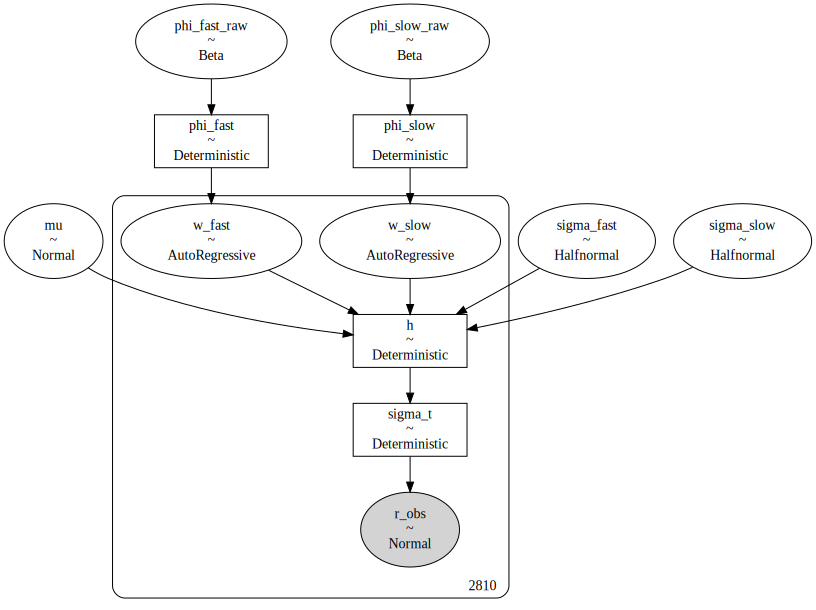

In [45]:
pm.model_to_graphviz(model_n225_2factor)

In [46]:
with pm.Model() as model_n225_2factor:
    mu = pm.Normal("mu", mu=np.log(np.var(r_vals)), sigma=2)

    # --- fast成分: 低め持続性に事前分布で強く制約 ---
    phi_fast_raw = pm.Beta("phi_fast_raw", alpha=2, beta=5)   # 平均0.29程度、0.7を超えにくい
    phi_fast = pm.Deterministic("phi_fast", phi_fast_raw)      # (0,1)のみ許容(負の持続性は今回不要)
    sigma_fast = pm.HalfNormal("sigma_fast", sigma=0.3)

    init_fast = pm.Normal.dist(0, 1 / pt.sqrt(1 - phi_fast**2))
    w_fast = pm.AR("w_fast", rho=phi_fast, sigma=1.0, init_dist=init_fast, shape=n)

    # --- slow成分: 高め持続性に強く制約(以前のphiに近いレンジ) ---
    phi_slow_raw = pm.Beta("phi_slow_raw", alpha=20, beta=1.5)  # 平均0.93程度
    phi_slow = pm.Deterministic("phi_slow", phi_slow_raw)
    sigma_slow = pm.HalfNormal("sigma_slow", sigma=0.15)

    init_slow = pm.Normal.dist(0, 1 / pt.sqrt(1 - phi_slow**2))
    w_slow = pm.AR("w_slow", rho=phi_slow, sigma=1.0, init_dist=init_slow, shape=n)

    # --- 合成 ---
    h = pm.Deterministic("h", mu + sigma_fast * w_fast + sigma_slow * w_slow)
    sigma_t = pm.Deterministic("sigma_t", pt.exp(h / 2))

    r_obs = pm.Normal("r_obs", mu=0, sigma=sigma_t, observed=r_vals)

    idata = pm.sample(draws=2000, tune=2000, chains=4, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, phi_fast_raw, sigma_fast, w_fast, phi_slow_raw, sigma_slow, w_slow]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 153 seconds.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [60]:
az.summary(idata, var_names=["mu", "sigma_fast", "sigma_slow", "phi_fast", "phi_slow"])


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,-9.08,0.13,-9.3,-8.9,584,857,1.01,0.0054,0.005
sigma_fast,0.525,0.058,0.43,0.62,639,1260,1.00,0.0023,0.0017
sigma_slow,0.158,0.039,0.099,0.22,137,192,1.02,0.0034,0.0028
phi_fast,0.56,0.11,0.36,0.71,136,162,1.02,0.01,0.0076
phi_slow,0.974,0.011,0.96,0.99,163,329,1.02,0.00087,0.00084


In [61]:
idata.sample_stats.diverging.sum().item()

0

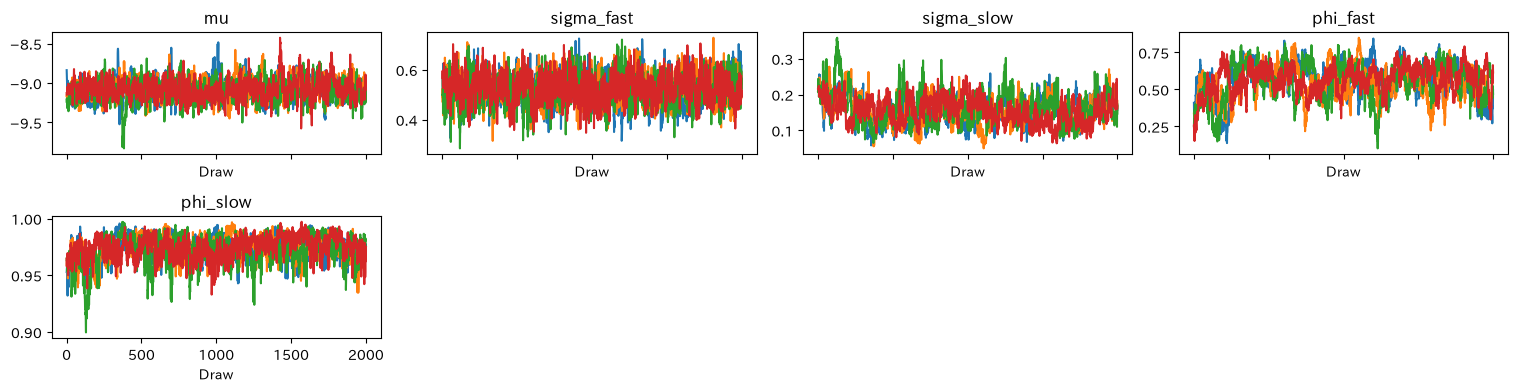

In [62]:
az.plot_trace(idata, var_names=["mu", "sigma_fast", "sigma_slow", "phi_fast", "phi_slow"])
plt.tight_layout()
plt.show()

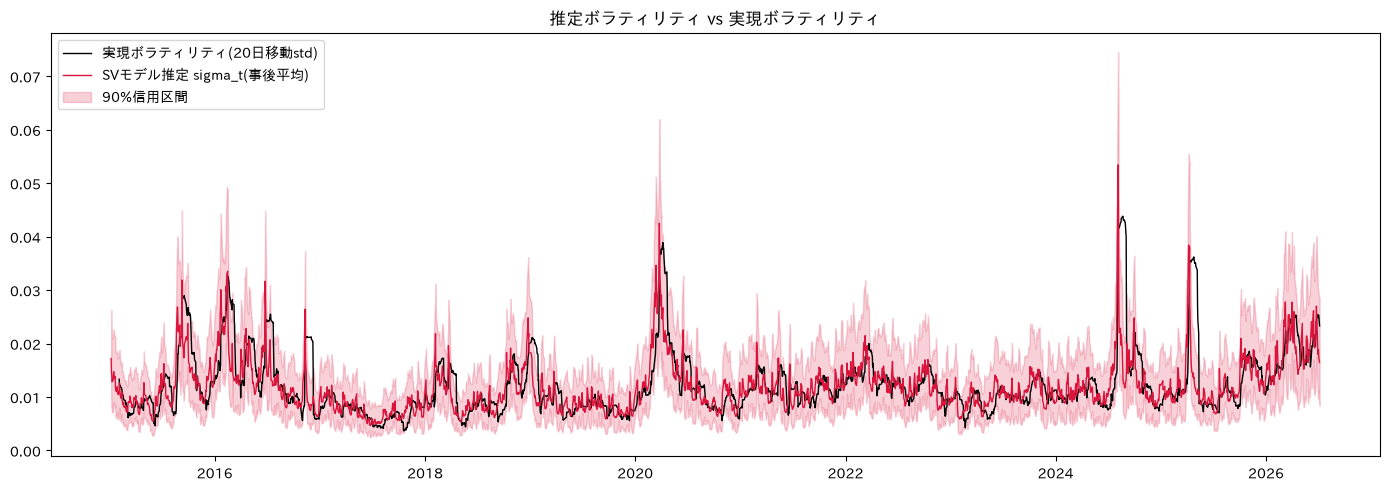

In [56]:
# --- 1. 推定ボラティリティ vs 実現ボラティリティ ---
h_posterior = idata.posterior["h"]
sigma_t_post = np.exp(h_posterior / 2)
sigma_t_stacked = sigma_t_post.stack(sample=("chain", "draw"))

sigma_mean = sigma_t_stacked.mean(dim="sample").values
sigma_lower = sigma_t_stacked.quantile(0.05, dim="sample").values
sigma_upper = sigma_t_stacked.quantile(0.95, dim="sample").values

realized_vol = pd.Series(r).rolling(20).std().values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[1:], realized_vol, color="black", lw=1, label="実現ボラティリティ(20日移動std)")
ax.plot(df.index[1:], sigma_mean, color="crimson", lw=1, label="SVモデル推定 sigma_t(事後平均)")
ax.fill_between(df.index[1:], sigma_lower, sigma_upper, color="crimson", alpha=0.2, label="90%信用区間")
ax.legend()
ax.set_title("推定ボラティリティ vs 実現ボラティリティ")
plt.tight_layout()
plt.savefig("col_comparison.png(model_n225_2factor).png", dpi=100)


Sampling: [r_obs]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

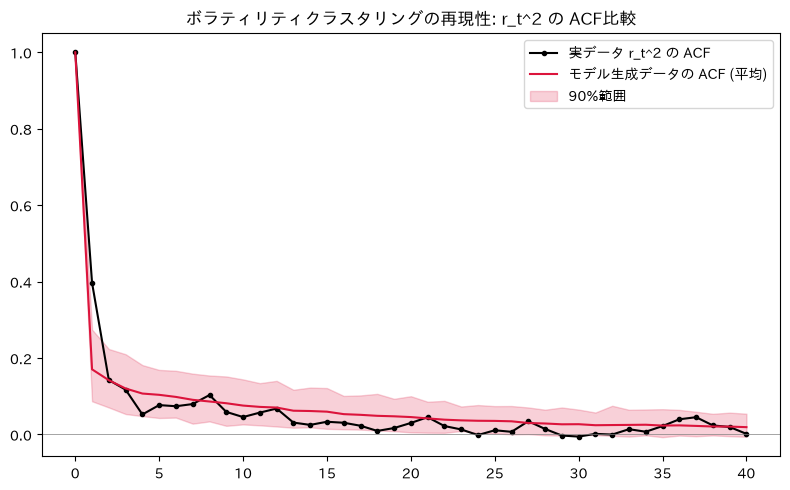

In [59]:
# --- 2. Posterior predictiveでボラティリティクラスタリングの再現性を検証 ---
with  model_n225_2factor:
    ppc = pm.sample_posterior_predictive(idata, var_names=["r_obs"], random_seed=42)

r_sim = ppc.posterior_predictive["r_obs"].stack(sample=("chain", "draw")).values.T

acf_real = acf(pd.Series(r).values**2, nlags=40)
acf_sims = np.array([acf(r_sim[i]**2, nlags=40) for i in range(min(200, r_sim.shape[0]))])
acf_sim_mean = acf_sims.mean(axis=0)
acf_sim_lower = np.percentile(acf_sims, 5, axis=0)
acf_sim_upper = np.percentile(acf_sims, 95, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
lags = np.arange(41)
ax.plot(lags, acf_real, color="black", marker="o", ms=3, label="実データ r_t^2 の ACF")
ax.plot(lags, acf_sim_mean, color="crimson", label="モデル生成データの ACF (平均)")
ax.fill_between(lags, acf_sim_lower, acf_sim_upper, color="crimson", alpha=0.2, label="90%範囲")
ax.axhline(0, color="gray", lw=0.5)
ax.legend()
ax.set_title("ボラティリティクラスタリングの再現性: r_t^2 の ACF比較")
plt.tight_layout()
plt.savefig("acf_comparison(student-T(model_n225_2factor)).png", dpi=100)


In [64]:
with pm.Model() as model_n225_2factor_boost:
    mu = pm.Normal("mu", mu=np.log(np.var(r_vals)), sigma=2)

    # --- fast成分: 低め持続性に事前分布で強く制約 ---
    phi_fast_raw = pm.Beta("phi_fast_raw", alpha=2, beta=5)   # 平均0.29程度、0.7を超えにくい
    phi_fast = pm.Deterministic("phi_fast", phi_fast_raw)      # (0,1)のみ許容(負の持続性は今回不要)
    sigma_fast = pm.HalfNormal("sigma_fast", sigma=0.3)

    init_fast = pm.Normal.dist(0, 1 / pt.sqrt(1 - phi_fast**2))
    w_fast = pm.AR("w_fast", rho=phi_fast, sigma=1.0, init_dist=init_fast, shape=n)

    # --- slow成分: 高め持続性に強く制約(以前のphiに近いレンジ) ---
    phi_slow_raw = pm.Beta("phi_slow_raw", alpha=20, beta=1.5)  # 平均0.93程度
    phi_slow = pm.Deterministic("phi_slow", phi_slow_raw)
    sigma_slow = pm.HalfNormal("sigma_slow", sigma=0.15)

    init_slow = pm.Normal.dist(0, 1 / pt.sqrt(1 - phi_slow**2))
    w_slow = pm.AR("w_slow", rho=phi_slow, sigma=1.0, init_dist=init_slow, shape=n)

    # --- 合成 ---
    h = pm.Deterministic("h", mu + sigma_fast * w_fast + sigma_slow * w_slow)
    sigma_t = pm.Deterministic("sigma_t", pt.exp(h / 2))

    r_obs = pm.Normal("r_obs", mu=0, sigma=sigma_t, observed=r_vals)

    idata = pm.sample(draws=4000, tune=2000, chains=4, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, phi_fast_raw, sigma_fast, w_fast, phi_slow_raw, sigma_slow, w_slow]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 276 seconds.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [65]:
az.summary(idata, var_names=["mu", "sigma_fast", "sigma_slow", "phi_fast", "phi_slow"])


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,-9.085,0.13,-9.3,-8.9,1072,1541,1.00,0.004,0.0037
sigma_fast,0.523,0.059,0.43,0.62,1041,1715,1.00,0.0019,0.0015
sigma_slow,0.161,0.041,0.1,0.23,262,360,1.01,0.0026,0.0021
phi_fast,0.55,0.11,0.36,0.71,232,261,1.01,0.0076,0.0062
phi_slow,0.973,0.012,0.95,0.99,318,465,1.00,0.00067,0.00061


In [66]:
idata.sample_stats.diverging.sum().item()

0

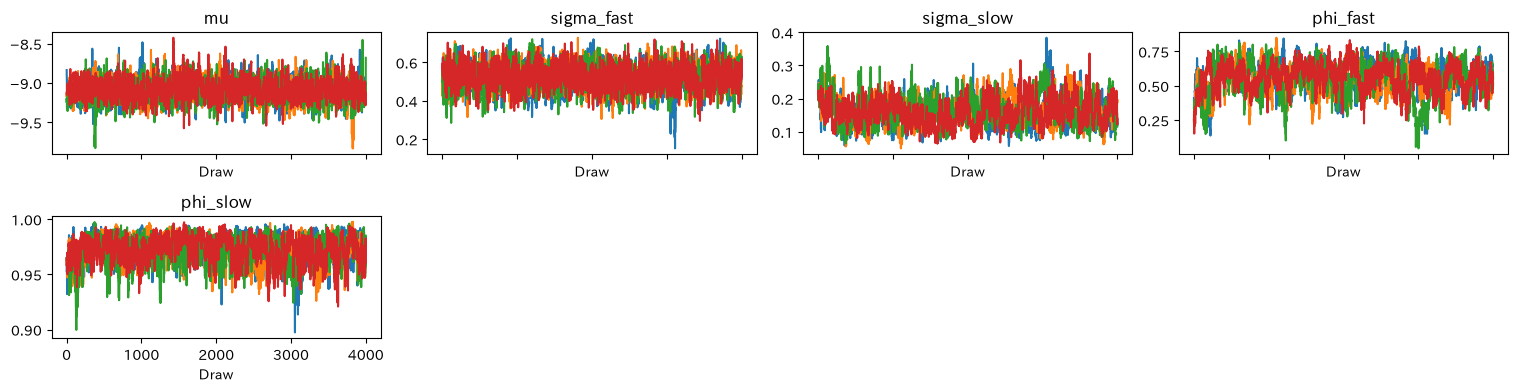

In [67]:
az.plot_trace(idata, var_names=["mu", "sigma_fast", "sigma_slow", "phi_fast", "phi_slow"])
plt.tight_layout()
plt.show()

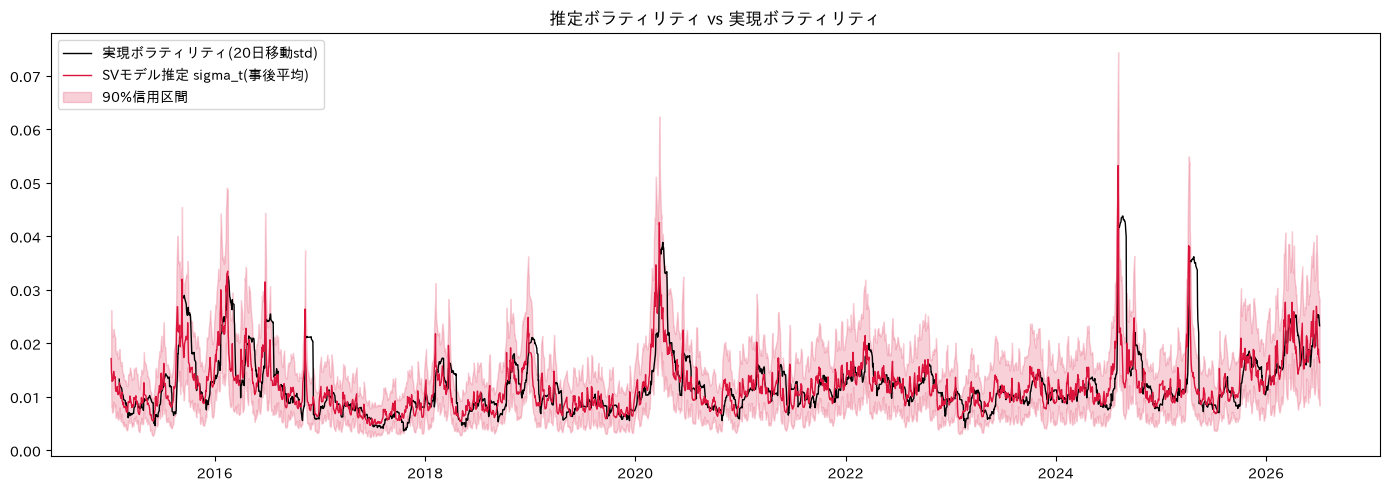

In [68]:
# --- 1. 推定ボラティリティ vs 実現ボラティリティ ---
h_posterior = idata.posterior["h"]
sigma_t_post = np.exp(h_posterior / 2)
sigma_t_stacked = sigma_t_post.stack(sample=("chain", "draw"))

sigma_mean = sigma_t_stacked.mean(dim="sample").values
sigma_lower = sigma_t_stacked.quantile(0.05, dim="sample").values
sigma_upper = sigma_t_stacked.quantile(0.95, dim="sample").values

realized_vol = pd.Series(r).rolling(20).std().values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[1:], realized_vol, color="black", lw=1, label="実現ボラティリティ(20日移動std)")
ax.plot(df.index[1:], sigma_mean, color="crimson", lw=1, label="SVモデル推定 sigma_t(事後平均)")
ax.fill_between(df.index[1:], sigma_lower, sigma_upper, color="crimson", alpha=0.2, label="90%信用区間")
ax.legend()
ax.set_title("推定ボラティリティ vs 実現ボラティリティ")
plt.tight_layout()
plt.savefig("col_comparison.png(model_n225_2factor).png", dpi=100)


Sampling: [r_obs]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

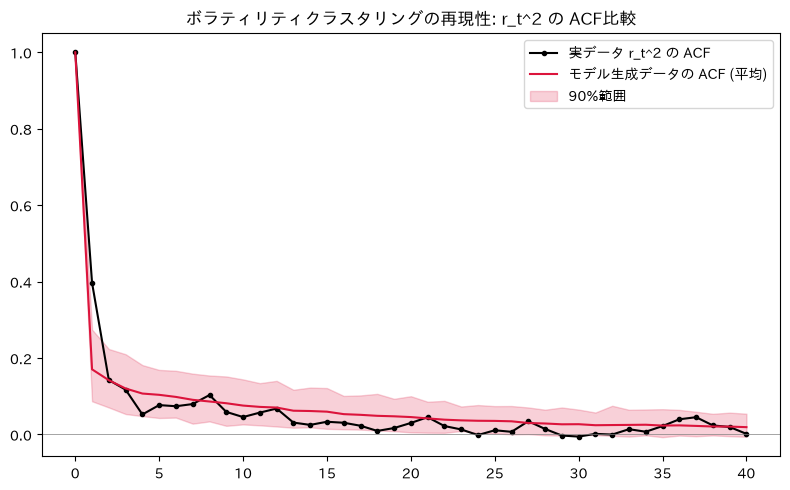

In [69]:
# --- 2. Posterior predictiveでボラティリティクラスタリングの再現性を検証 ---
with  model_n225_2factor_boost:
    ppc = pm.sample_posterior_predictive(idata, var_names=["r_obs"], random_seed=42)

r_sim = ppc.posterior_predictive["r_obs"].stack(sample=("chain", "draw")).values.T

acf_real = acf(pd.Series(r).values**2, nlags=40)
acf_sims = np.array([acf(r_sim[i]**2, nlags=40) for i in range(min(200, r_sim.shape[0]))])
acf_sim_mean = acf_sims.mean(axis=0)
acf_sim_lower = np.percentile(acf_sims, 5, axis=0)
acf_sim_upper = np.percentile(acf_sims, 95, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
lags = np.arange(41)
ax.plot(lags, acf_real, color="black", marker="o", ms=3, label="実データ r_t^2 の ACF")
ax.plot(lags, acf_sim_mean, color="crimson", label="モデル生成データの ACF (平均)")
ax.fill_between(lags, acf_sim_lower, acf_sim_upper, color="crimson", alpha=0.2, label="90%範囲")
ax.axhline(0, color="gray", lw=0.5)
ax.legend()
ax.set_title("ボラティリティクラスタリングの再現性: r_t^2 の ACF比較")
plt.tight_layout()
plt.savefig("acf_comparison(student-T(model_n225_2factor)).png", dpi=100)

ValueError: Keyword arguments ['kind', 'marginals'] have been passed as **kwargs but have no active aesthetic mapped to them. Keyword arguments must define values to use in their respective aesthetic mapping.

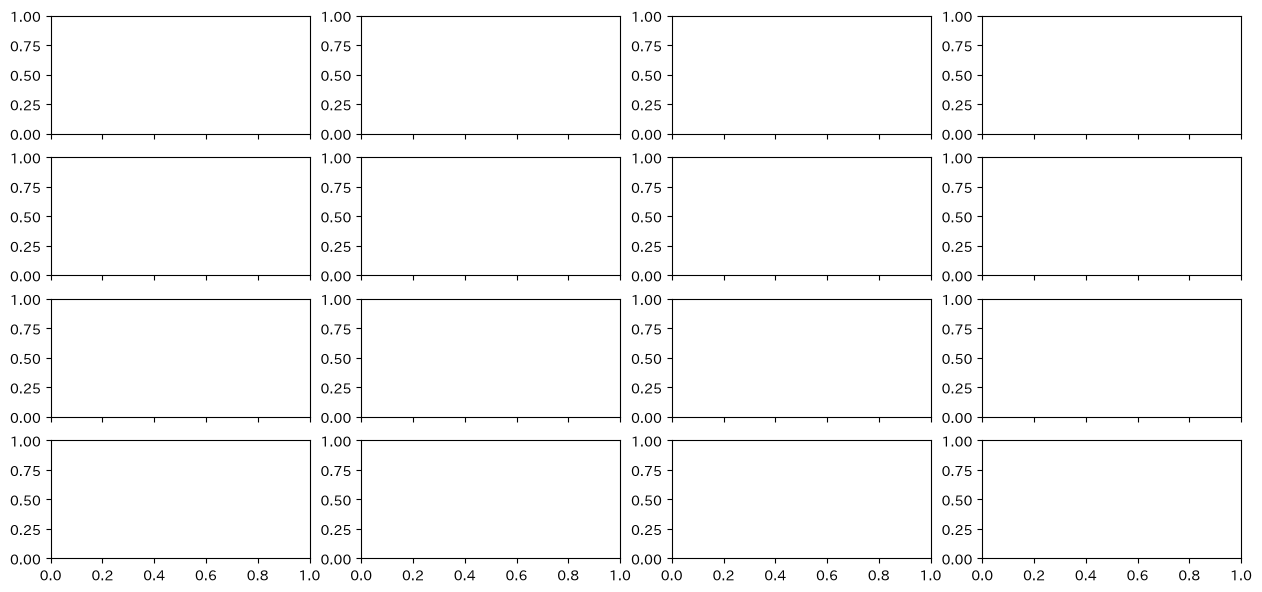

In [78]:
az.plot_pair(idata, var_names=["phi_fast", "phi_slow", "sigma_fast", "sigma_slow"], 
             kind="scatter", marginals=True)

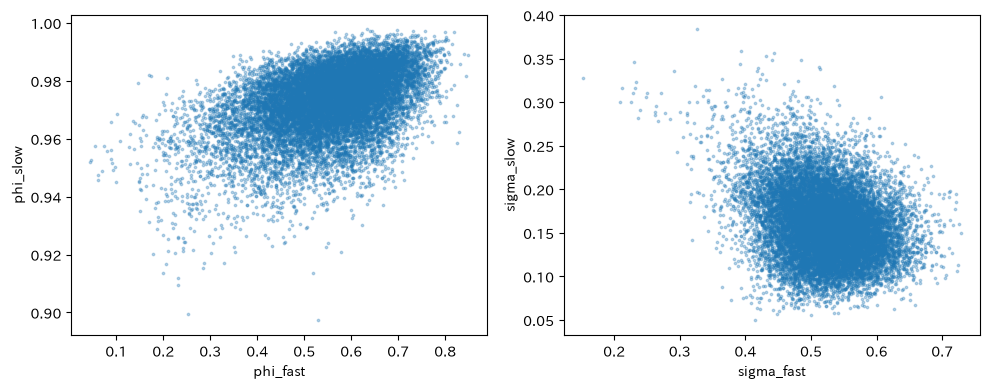

In [79]:
phi_fast = idata.posterior["phi_fast"].values.flatten()
phi_slow = idata.posterior["phi_slow"].values.flatten()
sigma_fast = idata.posterior["sigma_fast"].values.flatten()
sigma_slow = idata.posterior["sigma_slow"].values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(phi_fast, phi_slow, s=3, alpha=0.3)
axes[0].set_xlabel("phi_fast"); axes[0].set_ylabel("phi_slow")

axes[1].scatter(sigma_fast, sigma_slow, s=3, alpha=0.3)
axes[1].set_xlabel("sigma_fast"); axes[1].set_ylabel("sigma_slow")

plt.tight_layout()
plt.savefig("pair_check.png", dpi=100)

# 日経225 Stochastic Volatilityモデリング セッションサマリー

## 目的

PyMCでStochastic Volatility (SV) モデルを構築し、日経225の対数収益率(2015-01〜2026-07、n=2810)からボラティリティクラスタリングを捉える。Lynx個体数データ・Sunspot黒点数データでの状態空間モデル診断・改善の経験（特にnon-centered parameterizationとマルチモダリティの見極め）を引き継ぐ形で進めた。

---

## モデルの進化

### 1. Baseline: non-centered AR(1)-SV (正規分布観測)

$$r_t = \sigma_t \epsilon_t,\quad \epsilon_t\sim N(0,1), \qquad \sigma_t=\exp(h_t/2)$$
$$h_t = \mu + \sigma_\eta w_t,\quad w_t = \phi w_{t-1}+z_t$$

- **設計判断**: `pm.AR(rho=phi, sigma=1.0, ...)` で単位分散のAR(1)過程を作り、`sigma_eta`を外側から掛けることでnon-centered化。GaussianRandomWalkの非mean-reverting性を避け、AR(1)の平均回帰性を最初から組み込んだ。
- **診断の紆余曲折**: tune=500/draws=500では divergences=0だが $\hat R$(mu)=1.06、ess_bulk~200台という結果に。**マルチモダリティを疑ったが、チェーン別平均を比較したところ近い値だった**ため「チェーン長不足」と判断。tune=2000/draws=2000に伸ばしたところ $\hat R$=1.00、ess_bulk~1万まで改善し、仮説が正しかったことを確認。
- **推定値**: $\phi\approx0.91$–$0.92$、$\mu\approx-9.05$、$\sigma_\eta\approx0.35$–$0.36$
- **表現力の検証**: 推定ボラティリティ$\sigma_t$はCOVID急落(2020/3)・2024/8急落を含め、実現ボラティリティ(20日移動std)とレベル・タイミングともに良く一致。ただし posterior predictive の $r_t^2$ ACF比較で **lag=1のみ実データが90%範囲を明確に超過**（構造的なギャップ）。

### 2. Student-t観測分布への変更

$$r_t \sim \text{StudentT}(\nu, 0, \sigma_t)$$

- 動機: 正規分布は裾が軽く、単発の急変を表現しづらいと仮説。
- $\nu$の事前分布はGamma/Exponentialの2種を比較 → **ACFの形はほぼ不変**、頑健性は確認できたが問題は未解決。
- 事後: $\nu\approx14$（中程度の裾の重さ、事後sdも大きく強く絞り込まれていない）→ **裾の重さは主要因ではないと判断**。

### 3. Leverage effect (非対称SV) の導入

$$z_{t+1} = \rho u_t + \sqrt{1-\rho^2}v_t, \quad u_t = r_t/\sigma_t$$

- `pytensor.scan`で観測残差$u_t$から次期ショック$z_{t+1}$を構成する逐次モデルを手動実装（`pm.AR`では表現不可）。
- 結果: $\rho\approx-0.54$（89%区間 $[-0.61,-0.46]$）と、統計的に明確なレバレッジ効果を検出。診断も良好（$\hat R$=1.00、ess数千）。
- **しかしACF lag=1のギャップは解消されず**。$\rho$は「ショックの向き（非対称性）」を説明する一方、「ボラティリティがどれだけ速く動けるか」には効かないため、別問題だったと結論。「有意なパラメータ追加」と「本質的な問題解決」を混同しない、という原則が改めて効いた場面。

### 4. 2-factor (fast/slow) SV モデル

$$h_t = \mu + \sigma_\eta^{fast} w_t^{fast} + \sigma_\eta^{slow} w_t^{slow}$$

- fast成分・slow成分それぞれ独立なnon-centered AR(1)。label switching（fast/slowの入れ替わりによる多峰性、Sunspotの極形式パラメータ化と同種の問題）を避けるため、$\phi^{fast}\sim\text{Beta}(2,5)$（低持続性側）、$\phi^{slow}\sim\text{Beta}(20,1.5)$（高持続性側）と事前分布のレンジを意図的に分離。
- 結果: $\phi^{fast}\approx0.56$、$\phi^{slow}\approx0.974$、$\sigma^{fast}\approx0.53$、$\sigma^{slow}\approx0.16$。
- **ACF lag=1のギャップがほぼ解消**。leverage effectでは埋まらなかった箇所が、単一時間スケールの制約を外すことで説明できた。
- 診断は $\hat R$=1.01–1.02、ess_bulk 136–639とやや低め。トレースプロット上はチェーンの分離は見られず、baselineモデル初回実行と同様の「チェーン長不足」パターンと推定（要・本番相当runでの再確認、フォローアップ項目）。

---

## 主要な学び

1. **「有意なパラメータ」≠「問題の解決」**: leverage effectの$\rho$は統計的に明確でも、狙っていたACFギャップの解消には寄与しなかった。パラメータの有意性と、モデルが捉えたかった現象の再現は別軸で検証する必要がある。
2. **観測分布 vs 状態遷移構造、どちらが原因かの切り分け**: Student-t化（周辺分布の裾）とmulti-factor化（時間的なダイナミクスの自由度）は、どちらも「モデルを複雑化する」点は同じだが、解決するギャップの種類が異なる。lag=1のACF不足は後者で解決した。
3. **Divergence=0 & r_hat高値 → マルチモダリティを疑う、ただし即断しない**: 今回複数回このパターンに遭遇したが、**チェーン別の平均値を比較する**という一手間で「真の多峰性」か「単なるチェーン長不足」かを毎回切り分けられた。Sunspotの経験（真の多峰性）とは異なるケースが大半だった、という点も実務的な学び。
4. **識別性の設計は事前分布のレンジ分離で先回りできる**: 2-factorモデルのfast/slow成分は、対称な事前分布だと入れ替え問題が起きうるが、$\phi$のレンジを事前に分離しておくことで回避。

## 未解決・フォローアップ候補

- 2-factorモデルのess_bulkが低めなので、本番相当のチェーン長（tune=2000, draws=2000以上）で再実行し、r_hat改善を確認する
- leverage effect + 2-factorの同時導入は未検証（非対称性と時間スケールの両方を組み込んだフルモデル）
- `pymc-extras`の`statespace.structural`を使った構造化アプローチとの比較は今回は行わなかった
